In [37]:
import os
os.environ["JAX_PLATFORMS"] = 'cpu'
import jax.numpy as jnp
import jax 
import numpy as np
from utils import (
                  syn_group_ids_path,
                  collect_data,
                  torch_to_jax,
                  flatten_tokens_features,
                  depths,
                  reduce_list_half_preserve_extremes,
                  remove_syn_group_averages,
                  )
from geometry import normalized_L2_distance
from datapaths import * 
import matplotlib.pyplot as plt


In [38]:
min_token_length = 6
n_tokens = min_token_length
n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'syn'
avg_tokens = 0

input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]


In [39]:
all_activations_A = collect_data(input_path_A, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )

qwen7b dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:01<00:00, 11.50it/s]


all_hidden_states["layer_0"].shape=torch.Size([2098, 6, 3584])
importing took 0.052912084261576335 m


In [40]:
space_index = 'A'
global_center_flag = 1
act_A = {}
centers = {}
global_centers = {}
layers_A = np.array([5],dtype=int) # reduce_list_half_preserve_extremes(np.arange(1,depths[model_name]+1,dtype=int))

for layer_A in layers_A:
    activations_A = all_activations_A[f"layer_{layer_A}"]
    act_A[str(layer_A)] = torch_to_jax(activations_A[:,-n_tokens:,:],precision)
    act_A[str(layer_A)] = flatten_tokens_features(act_A[str(layer_A)])
    if global_center_flag:
        global_centers[str(layer_A)] = jnp.mean(act_A[str(layer_A)],axis=0)
        act_A[str(layer_A)] = act_A[str(layer_A)] - jnp.broadcast_to(global_centers[str(layer_A)],act_A[str(layer_A)].shape)
    else:
        global_centers[str(layer_A)] = None
    
    # syntax_centers
    centers_folder = f"/home/acevedo/syn-sem/results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_syn/modelA_qwen7b/modelB_qwen7b/match_var_matching/n_files_21/min_token_length_{min_token_length}/similarities/centers_syn/Nbits_0/n_tokens_{n_tokens}/avg_tokens_0/batch_shuffle_0/layer_A_{layer_A}/layer_B_{layer_A}/"
    centers[str(layer_A)] = jnp.array(np.load(os.path.join(centers_folder, f'syn_centers_{space_index}.npy'))).astype(jnp.float32) #(num_groups,E)
    
    if global_center_flag: # global centering syntax_centers...
        centers[str(layer_A)] = centers[str(layer_A)] - jnp.broadcast_to(global_centers[str(layer_A)],centers[str(layer_A)].shape)
    # all_indices = jnp.array(np.loadtxt(centers_folder + f'syn_all_indices.txt',dtype=int),dtype=jnp.int32)
    # all_counts = jnp.array(np.loadtxt(centers_folder + f'syn_all_counts.txt',dtype=int),dtype=jnp.int32)

print(f'{act_A[str(layer_A)].shape=}')
print(f'{centers[str(layer_A)].shape=}')

act_A[str(layer_A)].shape=(2098, 21504)
centers[str(layer_A)].shape=(96, 21504)


overlaps.mean()=Array(0.04001132, dtype=float32)
Distribution of overlaps between all centers


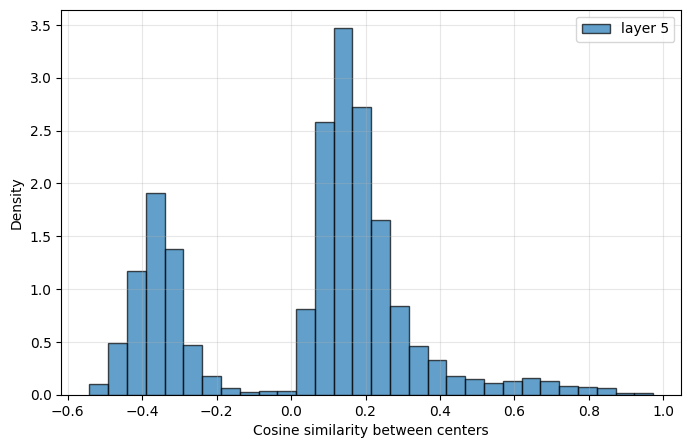

In [41]:
### OVERLAPS BETWEEN ALL CENTERS

import itertools

plt.figure(figsize=(8,5))

for layer_A in layers_A:

  # Normalize all centers
  normed_centers = centers[str(layer_A)] / jnp.linalg.norm(centers[str(layer_A)], axis=1, keepdims=True)  # shape: (n_centers, dim)

  # Compute all pairwise overlaps (excluding self-overlaps)
  n_centers = normed_centers.shape[0]
  overlaps = []
  for i, j in itertools.combinations(range(n_centers), 2):
      overlaps.append(jnp.dot(normed_centers[i], normed_centers[j]))
  overlaps = jnp.array(overlaps)
  print(f'{overlaps.mean()=}')

  # Plot histogram
  plt.hist(overlaps, bins=30, edgecolor='black', alpha=0.7, density=True, label=f'layer {layer_A}')
plt.xlabel('Cosine similarity between centers')
plt.ylabel('Density')
print(f'Distribution of overlaps between all centers')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Selected group 6 with 36 samples


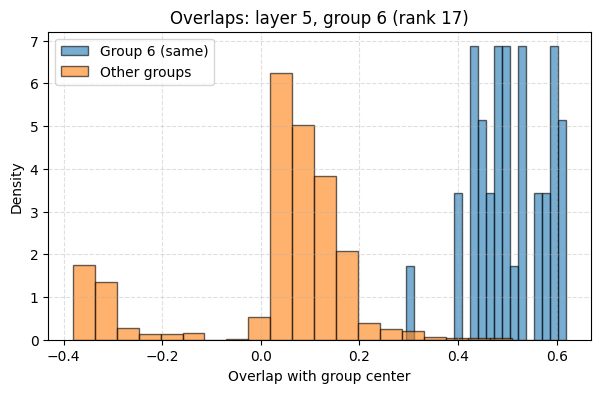

In [55]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

def compute_rowwise_cosine_similarity(act_A, act_B, eps=1e-8):
    """
    Compute row-wise cosine similarity between two activation matrices.

    Args:
        act_A (jnp.ndarray): shape (N, D), activations from space A
        act_B (jnp.ndarray): shape (N, D), activations from space B
        eps (float): small constant to avoid division by zero

    Returns:
        jnp.ndarray: shape (N,), cosine similarities for each row pair
    """
    numerator = jnp.sum(act_A * act_B, axis=1)
    denominator = jnp.linalg.norm(act_A, axis=1) * jnp.linalg.norm(act_B, axis=1)
    return numerator / (denominator + eps)


def plot_overlaps_with_centers_asserted(layer_A, centers, act_A, syn_group_ids_path, group_rank=1, bins=20):
    """
    Plot overlaps between activations and their group centers, with safety assertions.

    Args:
        layer_A: int, layer index
        centers: dict[str, jnp.ndarray], precomputed group centers
        act_A: dict[str, jnp.ndarray], activations
        syn_group_ids_path: str, path to file with group IDs
        group_rank: int, which group to use (0 = largest, 1 = second largest, etc.)
        bins: int, number of histogram bins
    """
    # load activations and centers
    acts = act_A[str(layer_A)]           # (N, E)
    all_centers = centers[str(layer_A)]  # (G, E)

    # load group IDs
    group_ids = jnp.array(np.atleast_1d(np.loadtxt(syn_group_ids_path, dtype=int)))  # (N,)

    # sanity checks
    unique_groups, counts = jnp.unique(group_ids, return_counts=True)
    assert len(unique_groups) == all_centers.shape[0], (
        f"Mismatch: {len(unique_groups)} groups but {all_centers.shape[0]} centers!"
    )

    # assert contiguous group IDs starting at 0
    expected_groups = jnp.arange(all_centers.shape[0])
    assert jnp.array_equal(unique_groups, expected_groups), (
        f"Group IDs must be contiguous [0..{all_centers.shape[0]-1}], "
        f"but got IDs: {np.array(unique_groups)}"
    )

    # sort groups by size descending
    sorted_idx = jnp.argsort(-counts)
    selected_group = int(unique_groups[sorted_idx[group_rank]])
    print(f"Selected group {selected_group} with {counts[sorted_idx[group_rank]]} samples")

    # get the center of that group
    center = all_centers[selected_group]  # safe because of assertion

    # compute overlaps using the helper
    overlaps = compute_rowwise_cosine_similarity(
        acts, jnp.tile(center, (acts.shape[0], 1))
    )

    # split by same vs different group
    same_mask = (group_ids == selected_group)
    diff_mask = ~same_mask

    same_overlaps = np.asarray(overlaps[same_mask])
    diff_overlaps = np.asarray(overlaps[diff_mask])

    # plot
    plt.figure(figsize=(7, 4))
    plt.hist(same_overlaps, bins=bins, alpha=0.6, color="tab:blue", edgecolor="black",
             density=True, label=f"Group {selected_group} (same)")
    plt.hist(diff_overlaps, bins=bins, alpha=0.6, color="tab:orange", edgecolor="black",
             density=True, label="Other groups")
    plt.xlabel("Overlap with group center")
    plt.ylabel("Density")
    plt.title(f"Overlaps: layer {layer_A}, group {selected_group} (rank {group_rank})")
    plt.legend()
    plt.grid(alpha=0.4, linestyle="--")
    plt.show()

plot_overlaps_with_centers_asserted(
    layer_A=5,
    centers=centers,
    act_A=act_A,
    syn_group_ids_path=syn_group_ids_path,
    group_rank=17, 
    bins=20
)



Selected group 6 with 36 samples


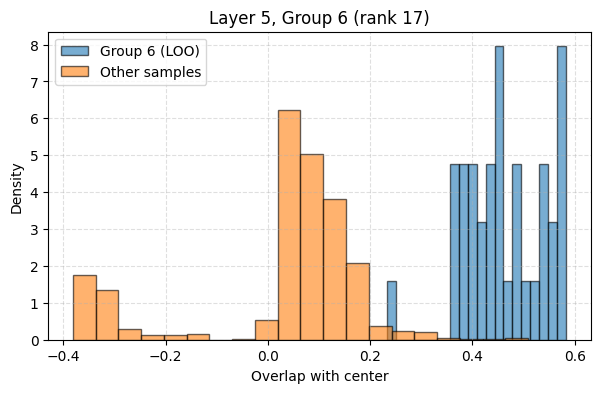

In [59]:
def plot_overlaps_with_LOO_vs_others(layer_A, centers, act_A, syn_group_ids_path, group_rank=1, bins=20, eps=1e-8):
    """
    Plot overlaps between activations and leave-one-out (LOO) centers for a selected group,
    and also show overlaps with all other samples (no LOO).

    Args:
        layer_A: int, layer index
        centers: dict[str, jnp.ndarray], precomputed group centers
        act_A: dict[str, jnp.ndarray], activations
        syn_group_ids_path: str, path to file with group IDs
        group_rank: int, which group to use (0 = largest, 1 = second largest, etc.)
        bins: int, number of histogram bins
        eps: float, small constant to avoid division by zero
    """
    # load activations and centers
    acts = act_A[str(layer_A)]           # (N, E)
    all_centers = centers[str(layer_A)]  # (G, E)

    # load group IDs
    group_ids = jnp.array(np.atleast_1d(np.loadtxt(syn_group_ids_path, dtype=int)))  # (N,)

    # sanity checks
    unique_groups, counts = jnp.unique(group_ids, return_counts=True)
    assert len(unique_groups) == all_centers.shape[0], (
        f"Mismatch: {len(unique_groups)} groups but {all_centers.shape[0]} centers!"
    )
    expected_groups = jnp.arange(all_centers.shape[0])
    assert jnp.array_equal(unique_groups, expected_groups), (
        f"Group IDs must be contiguous [0..{all_centers.shape[0]-1}], "
        f"but got IDs: {np.array(unique_groups)}"
    )

    # select the target group
    sorted_idx = jnp.argsort(-counts)
    selected_group = int(unique_groups[sorted_idx[group_rank]])
    print(f"Selected group {selected_group} with {counts[sorted_idx[group_rank]]} samples")

    # masks
    group_mask = (group_ids == selected_group)
    other_mask = ~group_mask

    # activations for the selected group and others
    acts_group = acts[group_mask]
    acts_other = acts[other_mask]

    # compute LOO centers for each sample in the selected group
    n_group = acts_group.shape[0]
    group_center = all_centers[selected_group]
    loo_centers = (n_group * group_center - acts_group) / (n_group - 1 + eps)

    # overlaps: LOO for own group
    overlaps_group_loo = compute_rowwise_cosine_similarity(acts_group, loo_centers, eps=eps)

    # overlaps: each sample in selected group vs all other samples (no LOO)
    # here we just compute cosine with the fixed group center for all other samples
    # (broadcasted)
    n_other = acts_other.shape[0]
    if n_other > 0:
        other_centers_for_group = jnp.tile(group_center, (n_other, 1))
        overlaps_with_others = compute_rowwise_cosine_similarity(acts_other, other_centers_for_group, eps=eps)
        overlaps_with_others = np.asarray(overlaps_with_others)
    else:
        overlaps_with_others = np.array([])

    # convert LOO overlaps to numpy
    overlaps_group_loo = np.asarray(overlaps_group_loo)

    # plot
    plt.figure(figsize=(7, 4))
    plt.hist(overlaps_group_loo, bins=bins, alpha=0.6, color="tab:blue", edgecolor="black",
             density=True, label=f"Group {selected_group} (LOO)")
    if overlaps_with_others.size > 0:
        plt.hist(overlaps_with_others, bins=bins, alpha=0.6, color="tab:orange", edgecolor="black",
                 density=True, label="Other samples")
    plt.xlabel("Overlap with center")
    plt.ylabel("Density")
    plt.title(f"Layer {layer_A}, Group {selected_group} (rank {group_rank})")
    plt.legend()
    plt.grid(alpha=0.4, linestyle="--")
    plt.show()

plot_overlaps_with_LOO_vs_others(
    layer_A=5,
    centers=centers,
    act_A=act_A,
    syn_group_ids_path=syn_group_ids_path,
    group_rank=17,
    bins=20
)


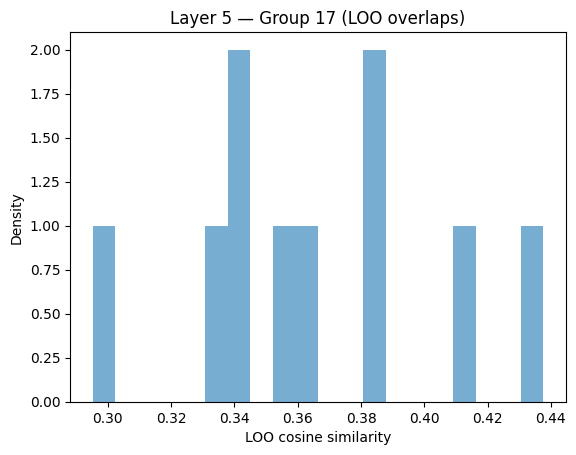

In [60]:
def compute_overlaps_with_LOO_per_sample(layer_A, centers, act_A, syn_group_ids_path, eps=1e-8):
    """
    Compute cosine similarity between each sample and its own group's leave-one-out center.

    Args:
        layer_A: int, layer index
        centers: dict[str, jnp.ndarray], precomputed group centers
        act_A: dict[str, jnp.ndarray], activations
        syn_group_ids_path: str, path to file with group IDs
        eps: float, small constant to avoid division by zero

    Returns:
        jnp.ndarray: shape (N,), cosine similarities for each sample with its LOO center
    """
    # load activations and centers
    acts = act_A[str(layer_A)]           # (N, E)
    all_centers = centers[str(layer_A)]  # (G, E)

    # load group IDs
    group_ids = jnp.array(np.atleast_1d(np.loadtxt(syn_group_ids_path, dtype=int)))  # (N,)

    # sanity checks
    unique_groups, counts = jnp.unique(group_ids, return_counts=True)
    assert len(unique_groups) == all_centers.shape[0], (
        f"Mismatch: {len(unique_groups)} groups but {all_centers.shape[0]} centers!"
    )
    expected_groups = jnp.arange(all_centers.shape[0])
    assert jnp.array_equal(unique_groups, expected_groups), (
        f"Group IDs must be contiguous [0..{all_centers.shape[0]-1}], "
        f"but got IDs: {np.array(unique_groups)}"
    )

    # prepare output array
    overlaps = jnp.zeros(group_ids.shape[0])

    # compute LOO overlaps per group
    for gid in unique_groups:
        mask = (group_ids == gid)
        acts_group = acts[mask]
        n_group = acts_group.shape[0]
        group_center = all_centers[gid]

        if n_group > 1:
            # LOO centers: (n_group, E)
            loo_centers = (n_group * group_center - acts_group) / (n_group - 1 + eps)
        else:
            # singleton group: fallback to the center itself
            loo_centers = acts_group  # or just group_center

        # compute cosine similarity
        overlaps_group = compute_rowwise_cosine_similarity(acts_group, loo_centers, eps=eps)
        overlaps = overlaps.at[mask].set(overlaps_group)

    return overlaps

overlaps_loo = compute_overlaps_with_LOO_per_sample(
    layer_A=5,
    centers=centers,
    act_A=act_A,
    syn_group_ids_path=syn_group_ids_path
)

# example: visualize histogram for a specific group
selected_group = 17
group_mask = jnp.array(np.loadtxt(syn_group_ids_path, dtype=int)) == selected_group
plt.hist(np.asarray(overlaps_loo[group_mask]), bins=20, alpha=0.6, color="tab:blue")
plt.xlabel("LOO cosine similarity")
plt.ylabel("Density")
plt.title(f"Layer 5 — Group {selected_group} (LOO overlaps)")
plt.show()

